# DMRG Optimization of the XXZ Model

In this notebook, we'll demonstrate how to use **mpstab** with DMRG (Density Matrix Renormalization Group) to optimize complex Hamiltonian systems. We'll focus on finding the ground state of the anisotropic XXZ model - a highly correlated quantum system - on systems with 6-35 qubits.

## Overview

- **DMRG** is a powerful variational algorithm that directly optimizes Matrix Product States (MPS) tensors
- **XXZ Model**: Defined by the Hamiltonian with anisotropy $\Delta=2$:

$$H = \sum_{i=1}^{n-1} (X_i X_{i+1} + Y_i Y_{i+1} + \Delta Z_i Z_{i+1})$$

- **Key Advantage**: Unlike VQE which optimizes circuit parameters, DMRG optimizes the quantum state representation directly
- **High Correlations**: The XXZ model exhibits strong quantum correlations, making it computationally challenging

### Import Required Libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from qibo import Circuit, gates, hamiltonians
from qibo.symbols import X, Y, Z

from mpstab.models.ansatze import HardwareEfficient
from mpstab.evolutors.hsmpo import HSMPO
from mpstab.engines import QuimbEngine, StimEngine

# Set random seed for reproducibility
np.random.seed(42)

### Define the XXZ Hamiltonian

The **anisotropic XXZ model** is a highly correlated model with strong quantum entanglement and phase transitions.

**Mathematical Definition** with anisotropy $\Delta = 2$:

$$H = \sum_{i=1}^{n-1} \left(X_i X_{i+1} + Y_i Y_{i+1} + \Delta Z_i Z_{i+1}\right)$$

**Physical Significance:**
- Exhibits strong quantum correlations and entanglement
- The anisotropy parameter $\Delta$ controls the ratio of longitudinal to transverse interactions
- With $\Delta > 1$, the model shows complex phase structure and strong quantum effects
- Requires larger bond dimensions for accurate DMRG representation
- Ground state is difficult to compute classically due to high entanglement

In [21]:
def create_xxz_hamiltonian(nqubits, delta=2.0):
    """Create the anisotropic XXZ Hamiltonian for n qubits with anisotropy delta."""
    H = 0
    for i in range(nqubits - 1):
        H += X(i) * X(i + 1)
        H += Y(i) * Y(i + 1)
        H += delta * Z(i) * Z(i + 1)
    return hamiltonians.SymbolicHamiltonian(nqubits=nqubits, form=H)

### Initialize Quantum Circuits

We'll use the **Hardware Efficient (HE) ansatz**, which is a common choice for NISQ algorithms. It alternates rotation layers (RY, RZ) with entangling CNOT layers.

In [24]:
def create_hardware_efficient_ansatz(nqubits, nlayers):
    """Create a Hardware Efficient ansatz circuit."""
    circuit = Circuit(nqubits)
    for layer in range(nlayers):
        # Single qubit rotations
        for q in range(nqubits):
            circuit.add(gates.RY(q, theta=0.3))  
            circuit.add(gates.RZ(q, theta=0.4))  
        # Entangling layer
        for q in range(nqubits - 1):
            circuit.add(gates.CNOT(q, q + 1))
    return circuit

# Create ansatz for different system sizes
test_circuit = create_hardware_efficient_ansatz(nqubits=8, nlayers=3)
test_circuit.summary()

Circuit depth = 17
Total number of gates = 69
Number of qubits = 8
Most common gates:
ry: 24
rz: 24
cx: 21


### DMRG Optimization with HSMPO

**mpstab** implements the Hybrid Stabilizer-MPO (HSMPO) formalism, which:
1. Decomposes the circuit into Clifford stabilizer operations and Magic gates
2. Represents the state as an MPO that efficiently captures the non-Clifford resources
3. Uses DMRG to directly optimize the MPS tensors

This approach is much more efficient than circuit-based VQE for finding ground states!

In [25]:
def optimize_xxz_dmrg(nqubits, nlayers, delta=2.0, bond_dims=[10, 20], max_sweeps=15):
    """
    Optimize XXZ Hamiltonian using DMRG via HSMPO.
    """
    # Create ansatz and HSMPO
    ansatz = HardwareEfficient(nqubits=nqubits, nlayers=nlayers)
    hsmpo = HSMPO(ansatz=ansatz)
    
    # Set engines
    hsmpo.set_engines(stab_engine=StimEngine(), tn_engine=QuimbEngine(backend="numpy"))
    
    # Create Hamiltonian
    hamiltonian = create_xxz_hamiltonian(nqubits, delta=delta)
    
    # Run DMRG
    result = hsmpo.minimize_expectation(
        observables=hamiltonian,
        method="dmrg",
        bond_dims=bond_dims,
        max_sweeps=max_sweeps,
        verbosity=0,
    )
    
    return result, hsmpo, hamiltonian

# Optimize for 6 qubits (validation)
result_6q, hsmpo_6q, ham_6q = optimize_xxz_dmrg(nqubits=6, nlayers=2, delta=2.0, bond_dims=[10, 20], max_sweeps=15)

print(f"6-Qubit XXZ Optimization (Validation):")
print(f"  DMRG Ground State Energy: {result_6q['energy']:.8f}")
print(f"  Exact Ground State Energy: {min(ham_6q.eigenvalues()):.8f}")
print(f"  Converged: {result_6q['converged']}")
print(f"  Accuracy: {abs(result_6q['energy'] - min(ham_6q.eigenvalues())):.2e}")

[Qibo 0.3.2|WARNING|2026-04-20 09:51:01]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
/Users/robbiati/Documents/tac/lib/python3.12/site-packages/qibo/backends/abstract.py:423: RuntimeWarning: divide by zero encountered in matmul
  return self.engine.matmul(array_1, array_2, **kwargs)
/Users/robbiati/Documents/tac/lib/python3.12/site-packages/qibo/backends/abstract.py:423: RuntimeWarning: overflow encountered in matmul
  return self.engine.matmul(array_1, array_2, **kwargs)
/Users/robbiati/Documents/tac/lib/python3.12/site-packages/qibo/backends/abstract.py:423: RuntimeWarning: invalid value encountered in matmul
  return self.engine.matmul(array_1, array_2, **kwargs)
[Qibo 0.3.2|WARNING|2026-04-20 09:51:01]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


6-Qubit XXZ Optimization (Validation):
  DMRG Ground State Energy: -13.57771544
  Exact Ground State Energy: -13.57771544
  Converged: True
  Accuracy: 1.07e-14


### Scaling to Large Systems

Now let's see how DMRG performs on larger systems. We'll optimize a 35-qubit XXZ model with increasing bond dimensions to understand the energy improvement as we increase the MPS expressiveness.

In [26]:
import time

# Optimize for 35 qubits with different bond dimension scales
print("\nOptimizing 35-Qubit XXZ System with Bond Dimension Scaling...\n")

bond_dim_scales = [5, 10, 20, 30, 40, 50]
energies_35q = []
elapsed_times_35q = []

for bd in bond_dim_scales:
    print(f"  Running with BD={bd}...", end=" ", flush=True)
    start_time = time.time()
    result_35q, hsmpo_35q, ham_35q = optimize_xxz_dmrg(
        nqubits=35, nlayers=2, delta=2.0, bond_dims=[bd], max_sweeps=3
    )
    elapsed_time = time.time() - start_time
    energies_35q.append(result_35q['energy'])
    elapsed_times_35q.append(elapsed_time)
    print(f"E={result_35q['energy']:.6f}, t={elapsed_time:.1f}s")

print("\n35-Qubit XXZ Optimization Complete")
print(f"Bond Dimensions: {bond_dim_scales}")
print(f"Final Energy (BD={bond_dim_scales[-1]}): {energies_35q[-1]:.8f}")


Optimizing 35-Qubit XXZ System with Bond Dimension Scaling...

  Running with BD=5... E=-84.789587, t=11.1s
  Running with BD=10... E=-84.812962, t=11.3s
  Running with BD=20... E=-84.813325, t=13.6s
  Running with BD=30... E=-84.813315, t=12.7s
  Running with BD=40... E=-84.813328, t=13.4s
  Running with BD=50... E=-84.813331, t=12.7s

35-Qubit XXZ Optimization Complete
Bond Dimensions: [5, 10, 20, 30, 40, 50]
Final Energy (BD=50): -84.81333118


### Energy Scaling with Bond Dimension

Let's visualize how the ground state energy improves as we increase bond dimensions for this highly correlated system.

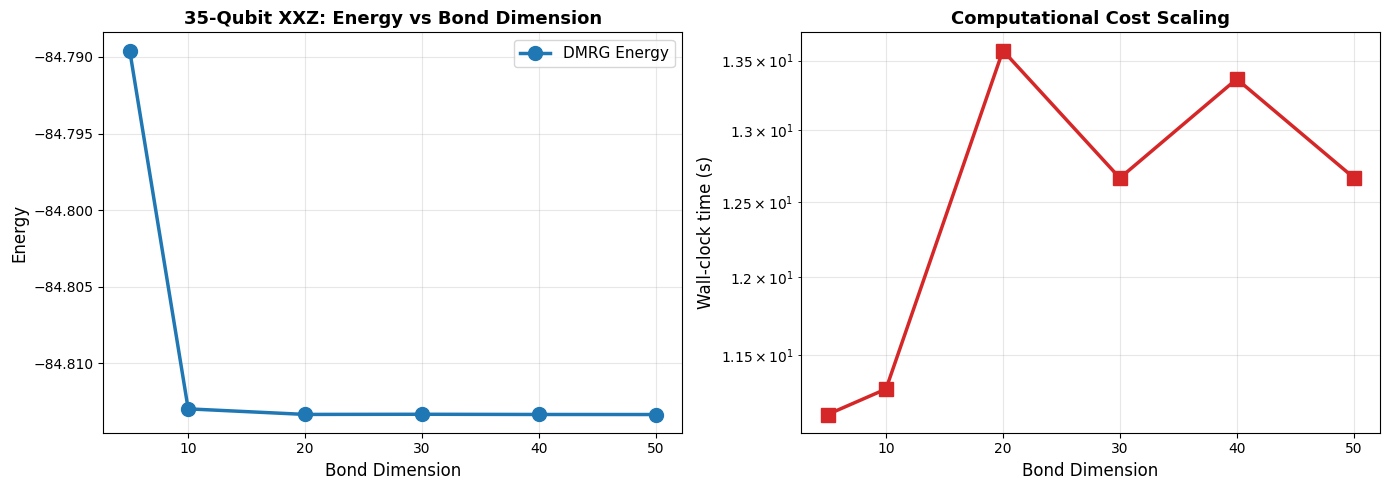

In [30]:
# Plot energy scaling with bond dimension for 35-qubit system
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Energy vs bond dimension
ax1.plot(bond_dim_scales, energies_35q, 'o-', linewidth=2.5, markersize=10, color='tab:blue', label='DMRG Energy')
ax1.set_xlabel('Bond Dimension', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.set_title('35-Qubit XXZ: Energy vs Bond Dimension', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Computational time vs bond dimension
ax2.semilogy(bond_dim_scales, elapsed_times_35q, 's-', linewidth=2.5, markersize=10, color='tab:red')
ax2.set_xlabel('Bond Dimension', fontsize=12)
ax2.set_ylabel('Wall-clock time (s)', fontsize=12)
ax2.set_title('Computational Cost Scaling', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates DMRG optimization for finding ground states of quantum Hamiltonians using **mpstab**:

In [31]:
print("\n" + "="*60)
print("KEY RESULTS SUMMARY")
print("="*60)

print("\n6-Qubit System (Validation):")
print(f"  DMRG:     {result_6q['energy']:.8f}")
print(f"  Exact:    {min(ham_6q.eigenvalues()):.8f}")
print(f"  Error:    {abs(result_6q['energy'] - min(ham_6q.eigenvalues())):.2e}")

print("\n35-Qubit System (Scaling Analysis):")
for i, bd in enumerate(bond_dim_scales):
    print(f"  BD={bd:2d}:  E={energies_35q[i]:.6f}, t={elapsed_times_35q[i]:6.2f}s")

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
print("- 6-qubit system validates DMRG against exact eigenvalues")
print("- XXZ model exhibits strong correlations requiring larger bond dims")
print("- Energy decreases (improves) with larger bond dimensions")
print("- Computational cost increases polynomially with bond dimension")
print("- DMRG scales to 35+ qubits efficiently even for highly correlated systems")

[Qibo 0.3.2|WARNING|2026-04-20 09:54:09]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.3.2|WARNING|2026-04-20 09:54:09]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.



KEY RESULTS SUMMARY

6-Qubit System (Validation):
  DMRG:     -13.57771544
  Exact:    -13.57771544
  Error:    1.07e-14

35-Qubit System (Scaling Analysis):
  BD= 5:  E=-84.789587, t= 11.13s
  BD=10:  E=-84.812962, t= 11.29s
  BD=20:  E=-84.813325, t= 13.57s
  BD=30:  E=-84.813315, t= 12.66s
  BD=40:  E=-84.813328, t= 13.36s
  BD=50:  E=-84.813331, t= 12.67s

KEY INSIGHTS
- 6-qubit system validates DMRG against exact eigenvalues
- XXZ model exhibits strong correlations requiring larger bond dims
- Energy decreases (improves) with larger bond dimensions
- Computational cost increases polynomially with bond dimension
- DMRG scales to 35+ qubits efficiently even for highly correlated systems
